<a href="https://colab.research.google.com/github/Chrisini/cosci-pygeon/blob/master/retina-cfp-vessel-segmentation-unlabelled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ℝ𝕖𝕥𝕚𝕟𝕒𝕝 𝕍𝕖𝕤𝕤𝕖𝕝 𝕊𝕖𝕘𝕞𝕖𝕟𝕥𝕒𝕥𝕚𝕠𝕟

Inspiration from:
- Frangi filter
- https://github.com/Brains-for-hire/bcosfire_python/blob/main/cosfire/cosfire.py

In [3]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import medmnist
    from medmnist import INFO
except:
    print("you have to install medmnist")
    !pip install medmnist
    import medmnist
    from medmnist import INFO

from torchvision import transforms


# Dataset

In [4]:
# choose dataset
data_flag = 'retinamnist'  # e.g. 'bloodmnist', 'tissuemnist', etc.

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# load datasets
dataset = DataClass(split='train', transform=transform, download=True, size=224)

print(dataset)
print(len(dataset))

# choose an image
img, label = dataset[5]

img = np.array(img)

# [-1, 1] → [0, 1]
img = (img + 1) / 2.0

# [0, 1] → [0, 255]
img = (img * 255).astype(np.uint8)

img_o = img

print("Label:", label)
print("Shape:", img.shape)

100%|██████████| 128M/128M [00:05<00:00, 23.6MB/s]


Dataset RetinaMNIST of size 224 (retinamnist_224)
    Number of datapoints: 1080
    Root location: /root/.medmnist
    Split: train
    Task: ordinal-regression
    Number of channels: 3
    Meaning of labels: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
    Number of samples: {'train': 1080, 'val': 120, 'test': 400}
    Description: The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.
    License: CC BY 4.0
1080
Label: [0]
Shape: (3, 224, 224)


# Segmentation

## Experiment 1: CLAHE + Frangi + postprocessing

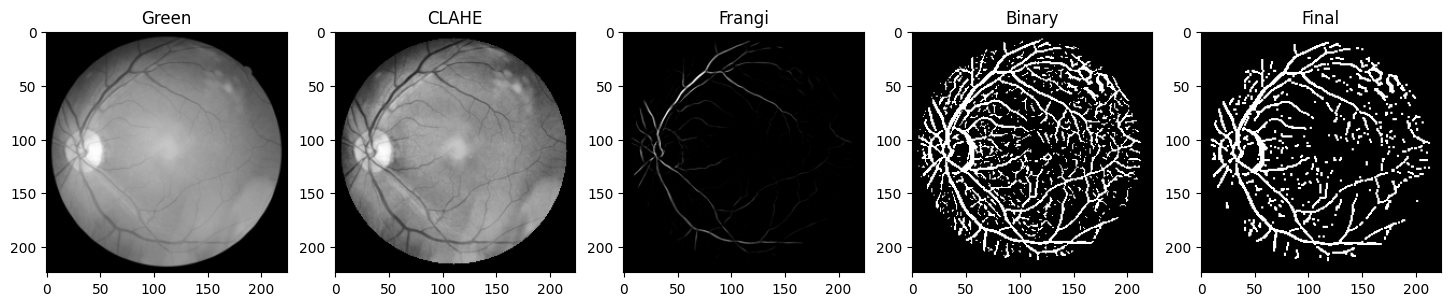

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi

img = img_o

# -------------------------
# Convert
# -------------------------
img = np.transpose(img, (1, 2, 0))

img = img.astype(np.uint8)

# -------------------------
# Green channel
# -------------------------
green = img[:, :, 1]

# -------------------------
# Fundus mask (circular)
# -------------------------
circles = cv2.HoughCircles(
    green,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=80,
    maxRadius=0
)

h, w = green.shape
mask = np.zeros((h, w), dtype=np.uint8)

if circles is not None:
    circles = np.round(circles[0]).astype(int)
    x, y, r = max(circles, key=lambda c: c[2])
    cv2.circle(mask, (x, y), r, 255, -1)
else:
    # fallback: assume full image is fundus
    mask[:] = 255

fundus = cv2.bitwise_and(green, green, mask=mask)

# -------------------------
# CLAHE
# -------------------------
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(fundus)

# -------------------------
# Optic disc mask
# -------------------------
od_thresh = np.percentile(enhanced[mask > 0], 99)

od_mask = ((enhanced > od_thresh) & (mask > 0)).astype(np.uint8)
od_mask = cv2.dilate(od_mask, np.ones((25,25), np.uint8))

# -------------------------
# Normalise for Frangi
# -------------------------
norm = enhanced.astype(np.float32) / 255.0

# -------------------------
# Frangi filter
# -------------------------
vessels = frangi(norm)

# -------------------------
# Apply masks (for optic disc and image circle)
# -------------------------
#vessels[od_mask == 1] = 0
vessels[mask == 0] = 0

# -------------------------
# Threshold
# -------------------------
th = np.percentile(vessels[mask > 0], 75)  # LOWER = more vessels
binary = (vessels > th).astype(np.uint8)

# -------------------------
# Postprocessing
# -------------------------
kernel = np.ones((2,2), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# -------------------------
# Visualization
# -------------------------
plt.figure(figsize=(18,8))

n=5

plt.subplot(1,n,1)
plt.title("Green")
plt.imshow(green, cmap='gray')

plt.subplot(1,n,2)
plt.title("CLAHE")
plt.imshow(enhanced, cmap='gray')

plt.subplot(1,n,3)
plt.title("Frangi")
plt.imshow(vessels, cmap='gray')

plt.subplot(1,n,4)
plt.title("Binary")
plt.imshow(binary*255, cmap='gray')

plt.subplot(1,n,5)
plt.title("Final")
plt.imshow(clean, cmap='gray')

plt.show()

## Experiment 2: CLAHE + ASF + background subtraction

- Green channel: best vessel contrast.
- CLAHE: enhances local contrast.
- Alternate Sequential Filtering (ASF): estimates the slowly varying background.
- Subtraction: makes dark vessels appear bright.
- Adaptive threshold: handles uneven illumination.
- Mask: removes border artifacts.

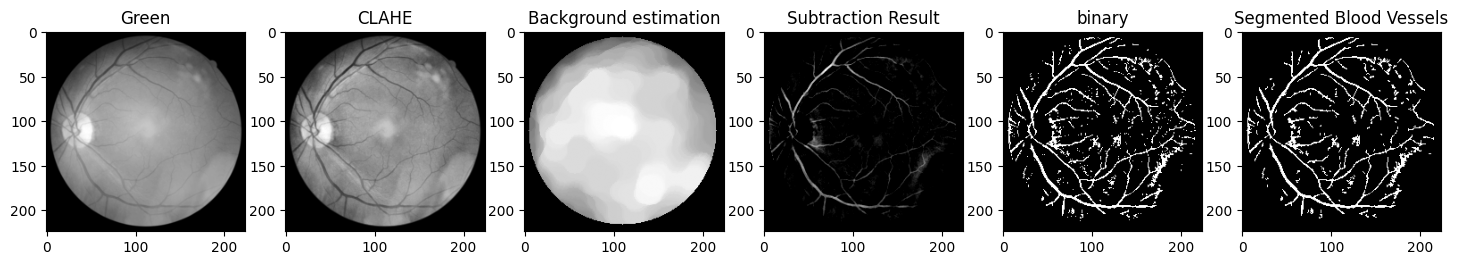

In [123]:
import cv2
import numpy as np
import os
import csv
from matplotlib import pyplot as plt

def extract_bv(img):

    green = img[:, :, 1]


    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    contrast_enhanced_green_fundus = clahe.apply(green)

    h, w = green.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    circles = cv2.HoughCircles(
        green,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=100,
        param1=100,
        param2=30,
        minRadius=80,
        maxRadius=0
    )


    if circles is not None:
        circles = np.round(circles[0]).astype(int)
        x, y, r = max(circles, key=lambda c: c[2])
        cv2.circle(mask, (x, y), r, 255, -1)
    else:
        # fallback: assume full image is fundus
        mask[:] = 255


    # applying alternate sequential filtering (3 times closing opening)
    r1 = cv2.morphologyEx(contrast_enhanced_green_fundus, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)), iterations = 1)
    R1 = cv2.morphologyEx(r1, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)), iterations = 1)
    r2 = cv2.morphologyEx(R1, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11)), iterations = 1)
    R2 = cv2.morphologyEx(r2, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11)), iterations = 1)
    r3 = cv2.morphologyEx(R2, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(23,23)), iterations = 1)
    R3 = cv2.morphologyEx(r3, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(23,23)), iterations = 1)
    R3 = cv2.bitwise_and(R3, R3, mask=mask)

    f4 = cv2.subtract(R3,contrast_enhanced_green_fundus)
    f5 = clahe.apply(f4)


    # -------------------------
    # Threshold
    # -------------------------
    binary = cv2.adaptiveThreshold(
        f5,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21,
        -5
    )


    binary[mask == 0] = 0

    # post processing
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

    clean = np.zeros_like(binary)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > 2:
            clean[labels == i] = 255


    titles = ['Green','CLAHE','Background estimation','Subtraction Result', 'binary','Segmented Blood Vessels']
    images = [green, contrast_enhanced_green_fundus, R3, f4, binary, clean]
    return images, titles



images, titles = extract_bv(img)

n = len(titles)
plt.figure(figsize=(18,8))
for i in range(n):
    plt.subplot(1,n,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    # plt.xticks([]),plt.yticks([])
plt.show()
